# 위험도 지표 생성

통학로 망(숭실대 315개·중앙대 280개 구간)에 위험도 지표 A·B·C를 따로 매긴다. 세 지표는 합치지 않는다.
규칙은 노션 "보행 위험도 지표 A·B·C 진행 방향"과 같다. A 계산 함수는 `risk_a_crossing.py`에 있다.

- A. 횡단 위험 — 교차 지점마다 0~4점
- B. 경사 위험 — 구간마다 양호·주의·위험
- C. 인지 복잡성 — 구간마다 판단 이벤트 수

진행 과정과 바뀐 결정은 바로 아래 "진행 과정과 결정 기록"에 정리했다.

## 진행 과정과 결정 기록 (2026-09-24)

아래 셀들은 최종 방식만 담고 있다. 여기에는 그 방식에 이르기까지 시도한 것, 바꾼 것, 그 이유를 순서대로 적는다.

### 출발점
- 처음 계획: A는 횡단 유형 4개에 점수를 주고, 순서 근거를 H3(음향신호기 없는 횡단보도가 사고다발지 근처에 더 많다)에서 찾으려 했음
- H3 서울 전체 결과가 반대 방향(음향신호기 **있는** 곳이 사고다발지 근처일 가능성 1.4~2.1배) → 음향신호기가 위험한 곳에 먼저 설치되는 역인과 때문에 사고 데이터로는 순서를 정할 수 없음
- => A·B·C는 **합치지 않고** 따로 만든다. A의 근거는 H3 대신 H7에서 이어진 "위험 대비 인프라 부족도"(노트북 08 §9·§11)

### A. 횡단 위험
1. **점수 방식**: 처음엔 §11의 1·2·3순위(부족 여부 × 음향신호기 유무)를 쓰려 했으나, 횡단 유형 4단계가 "음향 있음/없음" 둘로 줄어드는 문제 → 지원 점수(0~3) + 부족 점수(0~1) = **0~4점**을 그대로 쓰기로 함
2. **불일치 유형**(보행등 "무"인데 음향신호기가 배정됨): 원인을 구분할 수 없어 **보행등 없음(2점)**으로 분류. 확실하지 않은 음향신호기를 있다고 보면 위험한 곳이 안전하게 표시되기 때문. 실제 비율은 15.2%(처음에 적었던 27%는 예전 노트북의 다른 매칭 규칙 값)
3. **교차 지점 찾기 수정**: 교차로 중심점을 전체 OSM 그래프의 가장 가까운 노드에 붙였더니, 큰 교차로가 여러 노드로 그려져 있어 통학로 밖 노드에 붙는 바람에 숭실대 8곳이 빠짐 → **통학로 노드에 직접** 붙이도록 바꿈. 거리 분포가 0~20m에 몰리고 20~40m가 비어 있어 30m 기준 유지
4. **service 도로**: 차도로 보면 "횡단보도 없는 교차로"가 숭실대 19→126, 중앙대 29→157곳으로 폭증(대부분 진입로·주차장 통로) → **골목(service=alley)만 차도에 포함**, 나머지 service 도로는 제외(팀 결정)
5. **평가 범위**: 교차 지점이 없는 구간(통학로의 48~67%)에도 점수를 줄지 검토. 구간 대부분이 이면도로라 "차 옆을 걷는 위험"을 따로 매기는 방안도 나왔으나, A의 목적은 교차 지점의 횡단 위험이므로 **"A 적용 대상 아님"**으로 두기로 함
6. **학교 비교**: 종합 점수 = 점수가 있는 교차 지점의 평균 A 점수. 차이가 유의하지 않아(p=0.27) 1km당 3점 이상 지점 수와 위험 미확인 비율을 함께 봄

### B. 경사 위험
1. 처음 계획대로 **10m 조각**으로 계산 → 통학로의 74~86%가 "위험", 경사 100% 넘는 값까지 나와 비현실적
2. 원인 점검(B-0): 표고점을 빼고 등고선만으로 높이를 예측하니 오차 약 2m → 10m 조각의 경사 오차 ±28%p. 5.6%와 8.3%를 구분할 수 없음
3. 더 정밀한 높이 자료를 찾으려고 국토정보플랫폼 공개 DEM을 받았으나 **격자 간격 90m**라 더 거칠어서 사용 안 함(받은 파일 삭제)
4. => 오차가 ±5%p 안쪽이 되는 **60m 기준 길이**로 결정. 60m보다 짧은 구간은 구간 가운데를 중심으로 앞뒤 30m씩 재서 같은 오차 수준 유지
5. **급변(B-2)은 뺌**: 10m 단위 경사를 믿을 수 없어 이 데이터로는 잴 수 없음
6. 두 기준선 사이(2.7%p)보다 오차(±4.7%p)가 커서, 경사 0.9~13% 구간은 등급이 바뀔 수 있음 → **"기준선 근처"**로 표시하고 지도에서 점선 처리

### C. 이동 인지 복잡성
1. 45° 기준의 근거: TMAP 보행자 경로안내 API는 2시·10시 방향부터 회전을 안내함(1시·11시 코드 없음) → 1시와 2시 칸의 경계인 45°. 공식 기준은 없어서 30·45·60° × 5·10·20m 민감도로 확인
2. "10m 안에서 45°"로 급하게 꺾이는 것만 세도록 해서 완만한 곡선은 빠지게 함(반지름 50m 곡선 0회, 직각 1회로 확인)
3. **이단 횡단보도**: 처음엔 코드 뜻을 확인하지 못해 모든 횡단을 1로 셌음. 팀원이 "횡단보도-중간 지점-횡단보도" 형태임을 데이터에서 확인했고, 학술 정의("보행자가 도로를 두 번에 나누어 횡단하게 하는 횡단보도", 심관보 외 2013)도 같음 → **이단 2, 삼단 3**으로 반영. 서울시 테이블 정의서에는 코드 이름만 있고 뜻 설명은 없음
4. 이단을 반영하자 두 학교 차이가 벌어짐(1km당 5.55 vs 5.73 → 6.51 vs 7.18)

### 세 지표 요약
| | A 횡단 위험 (평균 점수) | B 경사 위험 (위험 길이 비율) | C 인지 복잡성 (1km당 이벤트) |
|---|---|---|---|
| 숭실대 | 2.44 | 51% | 6.51 |
| 중앙대 | 2.70 | 44% | 7.18 |

- A: 중앙대가 위험한 교차 지점이 더 많음. 숭실대는 위험 미확인이 59%라 낮게 나왔을 수 있음
- B: 숭실대가 조금 더 가파름. 다만 "확실한 위험" 비율은 두 학교가 같음(25%)
- C: 중앙대가 더 복잡함. 차이는 대부분 이단 횡단에서 나옴

## A. 횡단 위험

A 점수 = 지원 점수(0~3) + 부족 점수(0~1)

| 유형 | 지원 점수 | 부족 아님 | 부족 지역 |
|---|---|---|---|
| 보행등 + 음향신호기 | 0 | 0 | 1 |
| 보행등만 있음 | 1 | 1 | 2 |
| 보행등 없는 횡단보도 | 2 | 2 | 3 |
| 횡단보도 없는 교차로 | 3 | 3 | 4 |

- 부족 = 반경 500m 사고건수 합 ÷ 반경 500m 횡단보도 수가 서울 기준 상위 25% 이상
- 반경 500m 안에 사고다발지가 없으면 "위험 미확인" — 점수 없음
- 보행등 "무"인데 음향신호기가 배정된 불일치 유형은 2점

In [1]:
import importlib
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import h5_master
import crosswalk_deficiency as cd
import risk_a_crossing as ra
importlib.reload(ra)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

master, _, _ = h5_master.build_master()      # 서울 횡단보도 + 음향신호기 15m 배정
acc = cd.load_accidents()                     # 사고다발지 693곳
cw, acc, q = ra.seoul_crosswalks(500, master, acc)
print(f'서울 정상 좌표 횡단보도 {len(cw):,}곳, 반경 500m 안 사고가 있는 곳 {int((cw.위험 > 0).sum()):,}곳')
print(f'부족 기준값(서울 상위 25%): 사고건수/횡단보도수 >= {q:.3f}')

서울 정상 좌표 횡단보도 21,771곳, 반경 500m 안 사고가 있는 곳 9,183곳
부족 기준값(서울 상위 25%): 사고건수/횡단보도수 >= 0.853


### A-1. 교차 지점 찾기

- **횡단보도 있음**: 서울시 횡단보도를 교차로관리번호로 묶은 중심점을 가장 가까운 통학로 노드에 붙인다(30m 이내)
- **횡단보도 없는 교차로**: 차도 엣지 끝이 3개 이상 만나는 통학로 노드 중, 횡단보도가 붙지 않았고 30m 안에 횡단보도도 없는 곳
  - 차도 = residential 등급 이상 + 골목(OSM `service=alley`). 주차장 통로·진입로 등 나머지 service 도로는 차도로 보지 않는다 — A-4에서 전부 제외·전부 포함한 경우와 비교

30m 기준이 적절한지 보려고, 교차로 중심점에서 가장 가까운 통학로 노드까지의 거리 분포를 먼저 본다.

In [2]:
res = {s: ra.crossing_points(s, cw, acc, q) for s in ra.SCHOOLS}
bins = [0, 10, 20, 30, 40, 50, 75, 100]
dist = pd.DataFrame({s: pd.cut(d['교차로중심_스냅거리'], bins).value_counts().sort_index() for s, (_, d) in res.items()})
dist.index = [f'{int(i.left)}~{int(i.right)}m' for i in dist.index]
dist

,숭실대,중앙대
0~10m,15,24
10~20m,10,10
20~30m,0,2
30~40m,0,1
40~50m,1,2
50~75m,1,4
75~100m,1,8


- 표에서 20m 안쪽과 40m 바깥 사이가 비어 있으면, 30m 기준으로 잘리는 교차로가 거의 없다는 뜻이다
- 40m보다 멀리 있는 교차로는 통학로가 지나가지 않는 교차로로 본다

In [3]:
pts = pd.concat([p for p, _ in res.values()], ignore_index=True)
pd.crosstab(pts['학교'], pts['유형'], margins=True, margins_name='합계')

유형,횡단보도 없는 교차로,횡단보도 있음,합계
학교,,,
숭실대,19,25,44
중앙대,29,36,65
합계,48,61,109


### A-2. 점수 결과

In [4]:
order = ['보행등+음향', '보행등만', '보행등 없음', '횡단보도 없음']
t1 = pd.crosstab([pts['학교'], pts['지원수준']], pts['위험미확인'].map({False: '점수 있음', True: '위험 미확인'}))
t1 = t1.reindex(pd.MultiIndex.from_product([list(ra.SCHOOLS), order]), fill_value=0)
t1

위험미확인        위험 미확인  점수 있음
숭실대 보행등+음향        8      2
    보행등만          1      2
    보행등 없음        7      5
    횡단보도 없음      10      9
중앙대 보행등+음향        4      4
    보행등만          0      2
    보행등 없음        6     20
    횡단보도 없음      15     14

In [5]:
cols = ['0점', '1점', '2점', '3점', '4점', '위험 미확인']
def score_label(v):
    return '위험 미확인' if pd.isna(v) else f'{int(v)}점'
pd.crosstab(pts['학교'], pts['A점수'].map(score_label)).reindex(columns=cols, fill_value=0)

A점수,0점,1점,2점,3점,4점,위험 미확인
학교,,,,,,
숭실대,1,1,5,11,0,26
중앙대,2,2,9,20,7,25


서울 전체 횡단보도와 비교한다. 서울 전체에는 OSM 교차로 정보가 없어서 "횡단보도 없는 교차로"가 없다.
그래서 **횡단보도가 있는 교차 지점만** 서울과 같은 기준으로 나란히 본다.

In [6]:
seoul = ra.seoul_scores(cw)
comp = pd.DataFrame({'서울 전체 횡단보도': seoul['A점수'].value_counts(normalize=True)})
for s in ra.SCHOOLS:
    m = pts[(pts['학교'] == s) & (pts['유형'] == '횡단보도 있음') & pts['A점수'].notna()]
    comp[f'{s} (n={len(m)})'] = m['A점수'].value_counts(normalize=True)
comp = comp.reindex([0.0, 1.0, 2.0, 3.0]).fillna(0)
comp.index = [f'{int(i)}점' for i in comp.index]
(comp * 100).round(1).astype(str) + '%'

,서울 전체 횡단보도,숭실대 (n=9),중앙대 (n=26)
0점,32.8%,11.1%,7.7%
1점,22.3%,11.1%,7.7%
2점,34.2%,55.6%,34.6%
3점,10.7%,22.2%,50.0%


In [7]:
no_sig = cw['보행등유무'] != '유'
mismatch = no_sig & cw[ra.SIGNAL_COL].astype(float).eq(1)
print(f'서울 보행등 무 횡단보도 {int(no_sig.sum()):,}곳 중 음향신호기 배정(불일치) {int(mismatch.sum()):,}곳 = {mismatch.sum() / no_sig.sum():.1%}')
print('통학로 교차 지점 중 불일치 횡단보도가 있는 곳:', pts.groupby('학교')['불일치_수'].apply(lambda s: int((s.fillna(0) > 0).sum())).to_dict())

서울 보행등 무 횡단보도 8,252곳 중 음향신호기 배정(불일치) 1,251곳 = 15.2%
통학로 교차 지점 중 불일치 횡단보도가 있는 곳: {'숭실대': 3, '중앙대': 2}


### A-3. 지도

점수가 높을수록 진한 색. 원 = 횡단보도 있음, 네모 = 횡단보도 없는 교차로. 회색 빈 도형은 위험 미확인(점수 없음), 선은 통학로 구간.

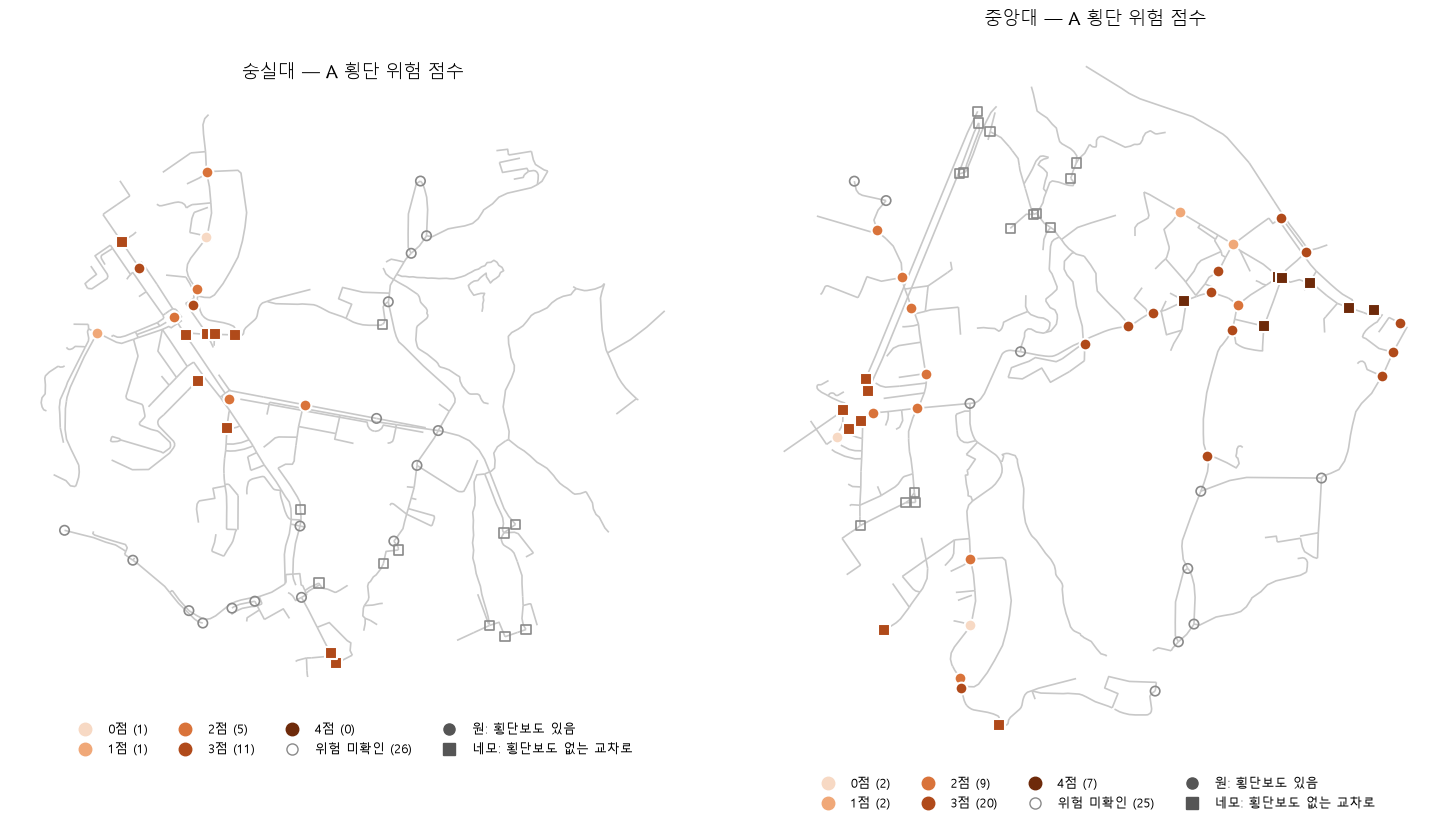

In [8]:
from matplotlib.lines import Line2D
RAMP = {0: '#F7D9C4', 1: '#F0A878', 2: '#D9733A', 3: '#B04A1A', 4: '#6E2A0A'}
MARK = {'횡단보도 있음': 'o', '횡단보도 없는 교차로': 's'}
Path('figures/risk_index').mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 8.5))
for ax, s in zip(axes, ra.SCHOOLS):
    _, _, an = ra.load_school(s)
    an.to_crs(ra.PROJ).plot(ax=ax, color='#C8C8C8', linewidth=1.2, zorder=1)
    p = pts[pts['학교'] == s]
    for typ, mk in MARK.items():
        un = p[p['A점수'].isna() & (p['유형'] == typ)]
        ax.scatter(un.x, un.y, s=46, marker=mk, facecolors='none', edgecolors='#8A8A8A', linewidths=1.2, zorder=2)
        for v in range(5):
            h = p[(p['A점수'] == v) & (p['유형'] == typ)]
            ax.scatter(h.x, h.y, s=72, marker=mk, color=RAMP[v], edgecolors='white', linewidths=1.5, zorder=3 + v)
    counts = p['A점수'].map(score_label).value_counts()
    handles = [Line2D([], [], marker='o', ls='', ms=9, color=RAMP[v], label=f'{v}점 ({counts.get(f"{v}점", 0)})') for v in range(5)]
    handles.append(Line2D([], [], marker='o', ls='', ms=8, mfc='none', mec='#8A8A8A', label=f'위험 미확인 ({counts.get("위험 미확인", 0)})'))
    handles += [Line2D([], [], marker='o', ls='', ms=8, color='#555555', label='원: 횡단보도 있음'),
                Line2D([], [], marker='s', ls='', ms=8, color='#555555', label='네모: 횡단보도 없는 교차로')]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=4, fontsize=9, frameon=False)
    ax.set_title(f'{s} — A 횡단 위험 점수', fontsize=13)
    ax.set_axis_off(); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('figures/risk_index/A_횡단위험_지도.png', dpi=150, bbox_inches='tight')
plt.show()

### A-4. 민감도

기준을 바꿔도 결과가 비슷한지 확인한다.

1. service 도로를 전부 제외 / 전부 포함 (기본은 골목만 포함)
2. 불일치 유형을 0점(보행등+음향)으로 분류
3. 반경 300m·800m (부족 기준값도 그 반경의 서울 상위 25%로 다시 계산)

In [9]:
def dist_row(p):
    return p['A점수'].map(score_label).value_counts().reindex(cols, fill_value=0)

rows = {}
for s in ra.SCHOOLS:
    rows[(s, '기본 (500m, 골목 포함)')] = dist_row(res[s][0])
    rows[(s, 'service 전부 제외')] = dist_row(ra.crossing_points(s, cw, acc, q, service_mode='none')[0])
    rows[(s, 'service 전부 포함')] = dist_row(ra.crossing_points(s, cw, acc, q, service_mode='all')[0])
    rows[(s, '불일치=0점')] = dist_row(ra.crossing_points(s, cw, acc, q, mismatch_as=0)[0])
for r in (300, 800):
    cw_r, _, q_r = ra.seoul_crosswalks(r, master, acc)
    for s in ra.SCHOOLS:
        rows[(s, f'반경 {r}m (기준값 {q_r:.2f})')] = dist_row(ra.crossing_points(s, cw_r, acc, q_r)[0])
sens = pd.DataFrame(rows).T.sort_index(level=0, sort_remaining=False)
sens

A점수                     0점  1점  2점  3점  4점  위험 미확인
숭실대 기본 (500m, 골목 포함)     1   1   5  11   0      26
    service 전부 제외        1   1   5   9   0      26
    service 전부 포함        1   1   5  62   7      75
    불일치=0점               1   1   6  10   0      26
    반경 300m (기준값 1.40)   0   4   3   5   1      31
    반경 800m (기준값 0.56)   9   4  12  17   0       2
중앙대 기본 (500m, 골목 포함)     2   2   9  20   7      25
    service 전부 제외        2   2   9  20   7      25
    service 전부 포함        2   2   9  82  36      62
    불일치=0점               2   2   9  20   7      25
    반경 300m (기준값 1.40)   1   4   2  11   6      41
    반경 800m (기준값 0.56)   5   4  12  32  10       2

service 도로를 전부 포함하면 기본(골목만 포함)보다 늘어나는 "횡단보도 없는 교차로"가 어떤 곳인지 본다.
기본 기준 차도 엣지가 0개면 service 도로끼리만 만나는 곳(주차장·단지 내부 등), 2개면 차도 옆으로 진입로가 붙는 곳이다.

In [10]:
svc_extra = {}
for s in ra.SCHOOLS:
    nodes, edges, an = ra.load_school(s)
    rn = set(an.u) | set(an.v)
    d0, d1 = ra.car_degree(edges, 'alley'), ra.car_degree(edges, 'all')
    extra = [n for n in rn if d1.get(n, 0) >= 3 and d0.get(n, 0) < 3]
    svc_extra[s] = pd.Series([int(d0.get(n, 0)) for n in extra]).value_counts().sort_index()
se = pd.DataFrame(svc_extra).fillna(0).astype(int)
se.index = [f'기본 기준 차도 엣지 {i}개' for i in se.index]
se

,숭실대,중앙대
기본 기준 차도 엣지 0개,47,49
기본 기준 차도 엣지 1개,4,6
기본 기준 차도 엣지 2개,73,102


### A-6. 구간별 비교와 학교 종합 점수

**구간 점수 매기는 규칙**
- A 점수는 교차 지점(노드)에 있으므로, 각 구간은 **양 끝 교차 지점 점수 중 큰 값**을 받는다. 그 구간을 걸으면 끝에서 그 교차 지점을 만나기 때문
- 양 끝이 모두 위험 미확인이면 "위험 미확인", 양 끝에 교차 지점이 없으면 "A 적용 대상 아님". A는 교차 지점의 횡단 위험만 평가하므로 이 구간은 점수를 매기지 않는다(안전하다는 뜻은 아님)

**학교 종합 점수**
- 종합 점수 = 점수가 있는 교차 지점들의 **평균 A 점수**(0~4). 높을수록 통학로의 횡단이 위험하다
- 종합 점수와 1km당 지표는 교차 지점만으로 계산한다. 구간 지도와 길이 비율은 위치를 보여주는 참고용이다
- 위험 미확인 지점은 평균에 들어가지 않으므로, 미확인 비율과 1km당 교차 지점 수를 함께 본다

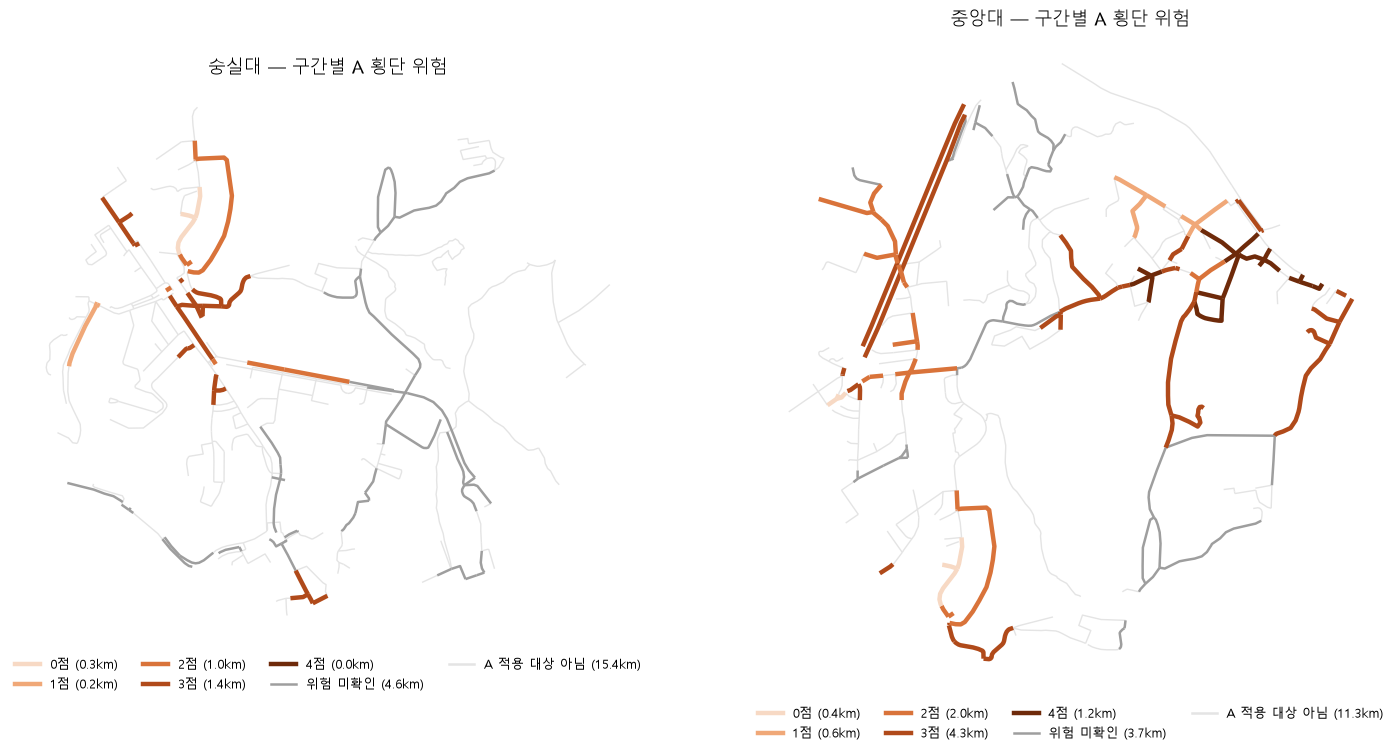

In [11]:
EDGE_CATS = ['0점', '1점', '2점', '3점', '4점', '위험 미확인', 'A 적용 대상 아님']
EDGE_COLOR = {**{f'{v}점': RAMP[v] for v in range(5)}, '위험 미확인': '#9E9E9E', 'A 적용 대상 아님': '#E4E4E4'}

def edge_scores(school):
    _, _, an = ra.load_school(school)
    an = an.to_crs(ra.PROJ).copy()
    p = pts[pts['학교'] == school].set_index('node')
    sc, has = p['A점수'], set(p.index)
    def cat(r):
        ends = [n for n in (r.u, r.v) if n in has]
        if not ends:
            return 'A 적용 대상 아님'
        vals = sc.reindex(ends).dropna()
        return f'{int(vals.max())}점' if len(vals) else '위험 미확인'
    an['A구간'] = an.apply(cat, axis=1)
    an['length_m'] = an.geometry.length
    return an

edges_a = {s: edge_scores(s) for s in ra.SCHOOLS}

fig, axes = plt.subplots(1, 2, figsize=(15, 8.5))
for ax, s in zip(axes, ra.SCHOOLS):
    e = edges_a[s]
    for z, c in enumerate(reversed(EDGE_CATS)):      # 옅은 것부터 그려서 진한 구간이 위에 오게
        g = e[e['A구간'] == c]
        if len(g):
            lw = 1.0 if c == 'A 적용 대상 아님' else (1.8 if c == '위험 미확인' else 3.2)
            g.plot(ax=ax, color=EDGE_COLOR[c], linewidth=lw, zorder=z + 1)
    km = e.groupby('A구간')['length_m'].sum() / 1000
    handles = [Line2D([], [], color=EDGE_COLOR[c], lw=3.2 if c.endswith('점') else 1.8,
                      label=f'{c} ({km.get(c, 0):.1f}km)') for c in EDGE_CATS]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=4, fontsize=9, frameon=False)
    ax.set_title(f'{s} — 구간별 A 횡단 위험', fontsize=13)
    ax.set_axis_off(); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('figures/risk_index/A_구간별_지도.png', dpi=150, bbox_inches='tight')
plt.show()

통학로 전체 길이 중 각 점수 구간이 차지하는 비율(참고용). "A 적용 대상 아님"은 건너는 지점과 이어지지 않은 구간이다. 막대의 진한 부분이 길수록 위험한 횡단과 이어진 구간이 많다.

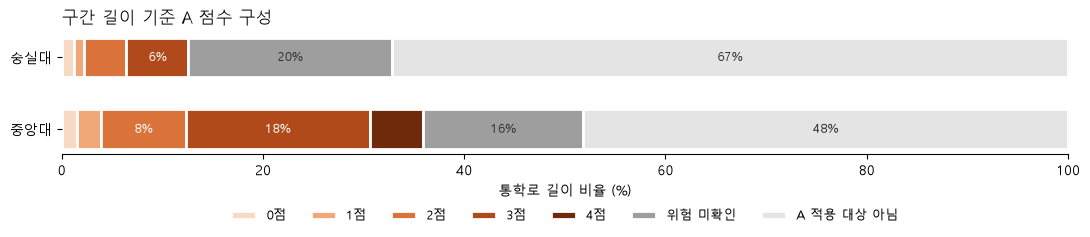

A구간,0점,1점,2점,3점,4점,위험 미확인,A 적용 대상 아님
숭실대,1.2%,1.0%,4.3%,6.2%,0.0%,20.2%,67.2%
중앙대,1.5%,2.4%,8.4%,18.3%,5.3%,15.9%,48.2%


In [12]:
share = pd.DataFrame({s: e.groupby('A구간')['length_m'].sum() for s, e in edges_a.items()}).T
share = share.reindex(columns=EDGE_CATS).fillna(0)
share_pct = share.div(share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 2.8))
left = np.zeros(len(share_pct))
for c in EDGE_CATS:
    w = share_pct[c].to_numpy()
    ax.barh(share_pct.index, w, left=left, color=EDGE_COLOR[c], edgecolor='white', linewidth=2, height=0.55, label=c)
    for yy, (l, v) in enumerate(zip(left, w)):
        if v >= 6:
            ax.text(l + v / 2, yy, f'{v:.0f}%', ha='center', va='center', fontsize=9,
                    color='white' if c in ('2점', '3점', '4점') else '#333333')
    left += w
ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel('통학로 길이 비율 (%)')
for sp in ('top', 'right', 'left'):
    ax.spines[sp].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=7, fontsize=9, frameon=False)
ax.set_title('구간 길이 기준 A 점수 구성', fontsize=12, loc='left')
plt.tight_layout()
plt.savefig('figures/risk_index/A_구간길이_구성.png', dpi=150, bbox_inches='tight')
plt.show()
share_pct.round(1).astype(str) + '%'

In [13]:
from scipy.stats import mannwhitneyu
rng = np.random.default_rng(20260924)
rows, scores = {}, {}
for s in ra.SCHOOLS:
    p = pts[pts['학교'] == s]
    sc = p['A점수'].dropna().to_numpy()
    scores[s] = sc
    boot = [rng.choice(sc, len(sc)).mean() for _ in range(5000)]
    km = edges_a[s]['length_m'].sum() / 1000
    rows[s] = {
        '종합 점수 (평균 A)': sc.mean(),
        '95% 구간 하한': np.percentile(boot, 2.5),
        '95% 구간 상한': np.percentile(boot, 97.5),
        '점수 있는 지점': len(sc),
        '위험 미확인 비율': p['A점수'].isna().mean(),
        '3점 이상 지점': int((sc >= 3).sum()),
        '통학로 길이 (km)': km,
        '1km당 교차 지점': len(p) / km,
        '1km당 3점 이상 지점': (sc >= 3).sum() / km,
    }
summary = pd.DataFrame(rows).T
u, pval = mannwhitneyu(*scores.values(), alternative='two-sided')
print(f'두 학교 A 점수 분포 차이 (Mann-Whitney U): U = {u:.0f}, p = {pval:.3f}')
summary.style.format({'종합 점수 (평균 A)': '{:.2f}', '95% 구간 하한': '{:.2f}', '95% 구간 상한': '{:.2f}',
                      '점수 있는 지점': '{:.0f}', '위험 미확인 비율': '{:.0%}', '3점 이상 지점': '{:.0f}',
                      '통학로 길이 (km)': '{:.1f}', '1km당 교차 지점': '{:.2f}', '1km당 3점 이상 지점': '{:.2f}'})

두 학교 A 점수 분포 차이 (Mann-Whitney U): U = 300, p = 0.269


,종합 점수 (평균 A),95% 구간 하한,95% 구간 상한,점수 있는 지점,위험 미확인 비율,3점 이상 지점,통학로 길이 (km),1km당 교차 지점,1km당 3점 이상 지점
숭실대,2.44,2.06,2.78,18,59%,11,22.9,1.92,0.48
중앙대,2.70,2.40,3.00,40,38%,27,23.4,2.78,1.15


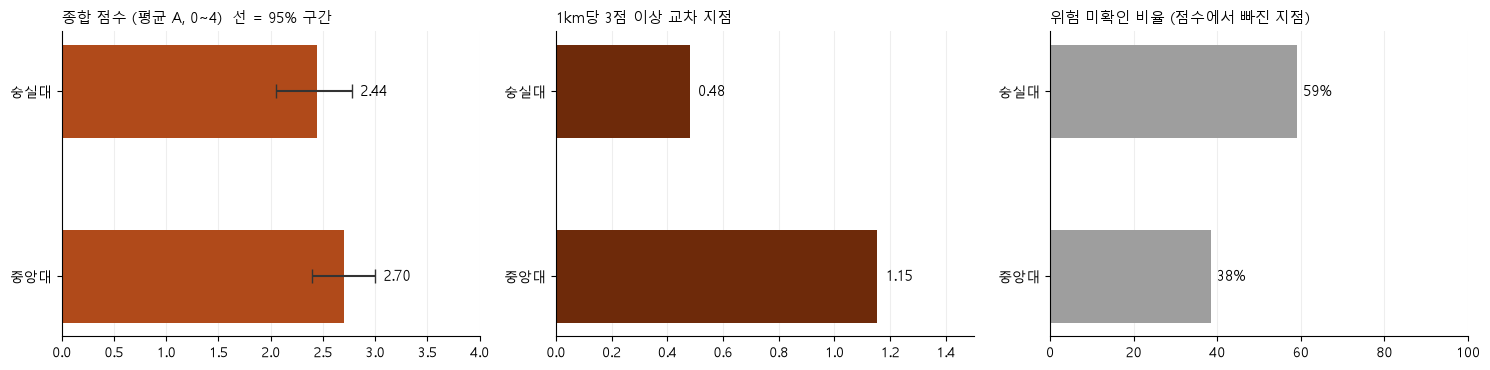

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
names = list(summary.index)
y = np.arange(len(names))

ax = axes[0]
m = summary['종합 점수 (평균 A)'].to_numpy(dtype=float)
lo = summary['95% 구간 하한'].to_numpy(dtype=float)
hi = summary['95% 구간 상한'].to_numpy(dtype=float)
ax.barh(y, m, color=RAMP[3], height=0.5)
ax.errorbar(m, y, xerr=[m - lo, hi - m], fmt='none', ecolor='#333333', capsize=5, lw=1.5)
for i, v in enumerate(m):
    ax.text(hi[i] + 0.08, i, f'{v:.2f}', va='center', fontsize=11)
ax.set_xlim(0, 4)
ax.set_title('종합 점수 (평균 A, 0~4)  선 = 95% 구간', fontsize=11, loc='left')

ax = axes[1]
v = summary['1km당 3점 이상 지점'].to_numpy(dtype=float)
ax.barh(y, v, color=RAMP[4], height=0.5)
for i, t in enumerate(v):
    ax.text(t + 0.03, i, f'{t:.2f}', va='center', fontsize=11)
ax.set_xlim(0, max(v) * 1.3)
ax.set_title('1km당 3점 이상 교차 지점', fontsize=11, loc='left')

ax = axes[2]
v = summary['위험 미확인 비율'].to_numpy(dtype=float) * 100
ax.barh(y, v, color='#9E9E9E', height=0.5)
for i, t in enumerate(v):
    ax.text(t + 1.5, i, f'{t:.0f}%', va='center', fontsize=11)
ax.set_xlim(0, 100)
ax.set_title('위험 미확인 비율 (점수에서 빠진 지점)', fontsize=11, loc='left')

for ax in axes:
    ax.set_yticks(y, names); ax.invert_yaxis()
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.grid(axis='x', color='#EEEEEE'); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('figures/risk_index/A_학교_종합비교.png', dpi=150, bbox_inches='tight')
plt.show()

### A-5. 저장

교차 지점별 결과를 `data/risk_index/A_crossing_points.csv`, `.geojson`으로 저장한다.

In [15]:
out = Path('data/risk_index'); out.mkdir(parents=True, exist_ok=True)
keep = ['학교', 'node', '유형', '지원수준', '지원점수_최대', '횡단보도수', '횡단단수_최대', '이단_수', '보행등없음_수', '음향_수', '불일치_수',
        '위험', '인프라', '부족', '위험미확인', 'A점수', '차도_엣지수', '교차로관리번호', 'x', 'y', 'lon', 'lat']
pts[keep].to_csv(out / 'A_crossing_points.csv', index=False, encoding='utf-8-sig')
gpd.GeoDataFrame(pts[keep], geometry=gpd.points_from_xy(pts.lon, pts.lat), crs='EPSG:4326').to_file(
    out / 'A_crossing_points.geojson', driver='GeoJSON')
print(len(pts), '개 교차 지점 저장')

109 개 교차 지점 저장


## B. 경사 위험

- **B 등급**: 구간의 최대 경사가 5.6%(1/18) 이하 양호 / 8.3%(1/12) 이하 주의 / 초과 위험
  - 기준 출처: 「장애인·노인·임산부 등의 편의증진 보장에 관한 법률 시행규칙」 [별표 1] 제1호 접근로 기울기
- 높이는 등고선(5m 간격) 정점 + 표고점을 선형 보간해서 구한다 (`compute_edge_slope.py`와 같은 방식). 계산 함수는 `risk_b_slope.py`
- 경사는 **60m 이상 기준 길이**로 잰다 (이유는 B-0). 처음 계획한 10m 조각과 B-2 급변은 데이터 해상도 한계로 뺐다

### B-0. 데이터 해상도 점검 — 10m 조각이 가능한가

계획은 구간을 10m 조각으로 나누는 것이었다. 먼저 높이 데이터가 그만큼 정밀한지 확인한다.

In [16]:
import risk_b_slope as rb
importlib.reload(rb)
nets_b = {s: ra.load_school(s)[2].to_crs(rb.PROJ) for s in ra.SCHOOLS}
area_b = rb.study_area(nets_b)
samples_b = rb.load_elevation_samples(area_b)
err = rb.spot_height_error(area_b)
rmse = np.sqrt((err ** 2).mean())
print(f'표고점 {len(err)}개를 빼고 등고선만으로 그 높이를 예측한 오차')
print(f'  RMSE {rmse:.2f}m / 절대오차 중앙값 {np.median(np.abs(err)):.2f}m / 90분위 {np.quantile(np.abs(err), 0.9):.2f}m')
pd.DataFrame({'조각 길이': [f'{L}m' for L in (10, 20, 30, 50, 60)],
              '경사 오차 (대략, ±%p)': [round(np.sqrt(2) * rmse / L * 100, 1) for L in (10, 20, 30, 50, 60)]}).set_index('조각 길이')

표고점 330개를 빼고 등고선만으로 그 높이를 예측한 오차
  RMSE 1.98m / 절대오차 중앙값 1.06m / 90분위 3.10m


,"경사 오차 (대략, ±%p)"
조각 길이,
10m,28.0
20m,14.0
30m,9.3
50m,5.6
60m,4.7


- 경사 오차는 두 끝점의 높이 오차가 서로 독립이라고 보고 계산한 대략값이다 (√2 × RMSE ÷ 조각 길이)
- 표고점은 봉우리·안부처럼 보간이 어려운 곳에 찍히는 경우가 많아, 길 위의 실제 오차는 이보다 작을 수 있다

In [17]:
sens_b = pd.concat({s: rb.piece_length_sensitivity(n, samples_b) for s, n in nets_b.items()})
sens_b.round(1)

양호 길이%  주의 길이%  위험 길이%  최대경사 중앙값%   급변 수
숭실대 10m     6.6     7.6    85.9       12.4  358.0
    20m    12.2     8.3    79.5       10.1  200.0
    30m    14.7    14.2    71.1        8.6   94.0
    50m    20.7    16.7    62.7        7.5   38.0
중앙대 10m    21.3     4.4    74.3       10.8  343.0
    20m    23.4     6.4    70.1        8.5  200.0
    30m    26.6     8.0    65.3        7.5  106.0
    50m    34.0    11.1    54.9        5.3   47.0

**판단**
- 높이 오차가 약 2m라서, 10m 조각의 경사 오차는 ±28%p 정도다. 5.6%와 8.3%(차이 2.7%p)를 구분할 수 없다
- 조각 길이를 늘리면 "위험" 비율과 급변 수가 크게 줄어든다 → 10m 조각에서 나온 값의 상당 부분은 지형이 아니라 보간 오차다
- 국토정보플랫폼 공개 DEM도 확인했지만 격자 간격이 90m라 더 거칠었다
- => **경사는 60m 기준 길이로 잰다**(오차 약 ±4.7%p). 10m 단위 급변(B-2)은 이 데이터로 잴 수 없어 뺀다

### B-1. 구간별 경사 계산

- 60m 이상 구간: 60m 이상 조각으로 나눠(조각 수 = 구간 길이 ÷ 60의 몫) 조각마다 경사를 재고, 가장 가파른 조각 값을 쓴다
- 60m 미만 구간: 구간 가운데를 중심으로 구간 방향(시작점 → 끝점)으로 앞뒤 30m씩, 60m 길이로 잰다. 짧은 구간도 같은 오차 수준으로 재기 위해서다
- **기준선 근처**: 최대 경사가 5.6% 또는 8.3%에서 ±4.7%p 안에 있어, 오차 때문에 등급이 바뀔 수 있는 구간

In [18]:
b_edges = {s: rb.score_b(n, samples_b) for s, n in nets_b.items()}
bsum = {}
for s, e in b_edges.items():
    L = e['length_m'].sum()
    bsum[s] = {
        '구간 수': len(e),
        **{f'{g} 길이%': e.loc[e['B등급'] == g, 'length_m'].sum() / L * 100 for g in rb.GRADES},
        '최대경사 중앙값%': e['최대경사_pct'].median(),
        '60m 미만 구간': int((e['length_m'] < rb.BASE_M).sum()),
        '기준선 근처 구간': int(e['기준선_근처'].sum()),
        '계단 구간': int(e['계단'].sum()),
    }
pd.DataFrame(bsum).T.round(1)

,구간 수,양호 길이%,주의 길이%,위험 길이%,최대경사 중앙값%,60m 미만 구간,기준선 근처 구간,계단 구간
숭실대,315.0,27.3,22.1,50.6,6.8,183.0,239.0,3.0
중앙대,280.0,36.8,18.9,44.3,4.5,146.0,188.0,4.0


- 두 기준선 사이가 2.7%p밖에 안 되고 경사 오차는 ±4.7%p라서, 경사 0.9~13% 구간은 모두 "기준선 근처"가 된다
- 그래서 **등급이 확실한 구간은 아주 완만하거나(0.9% 미만) 아주 가파른(13% 초과) 구간뿐**이다. 지도에서는 기준선 근처 구간을 점선으로 따로 표시한다

### B-2. 지도

진할수록 가파르다. 실선 = 등급이 확실한 구간, 점선 = 기준선 근처(오차 범위 안). 검은 선 = 계단.

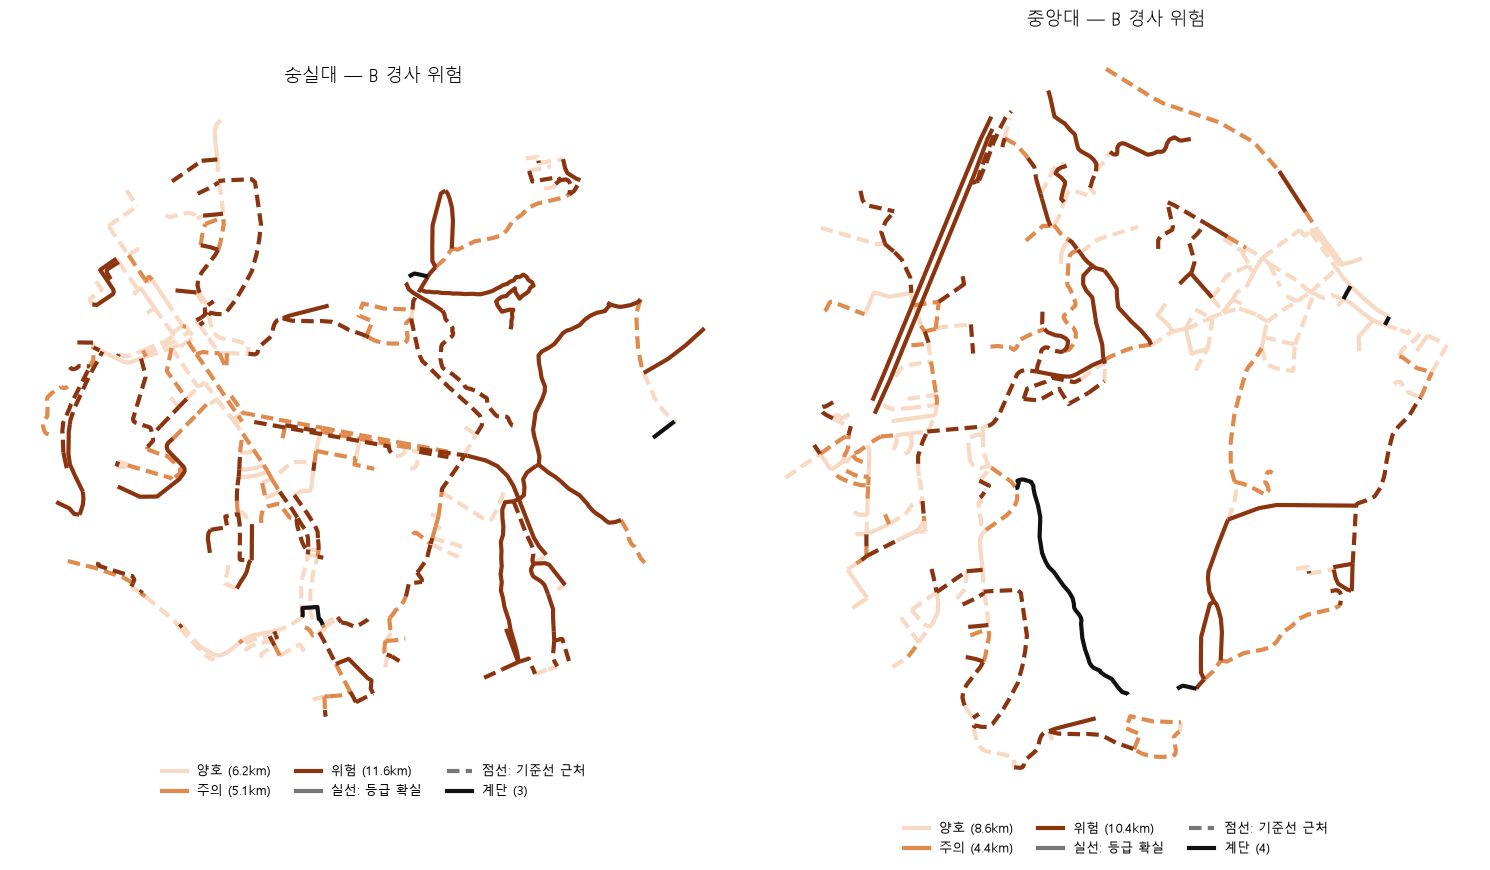

In [19]:
B_COLOR = {'양호': '#F7D9C4', '주의': '#E08A4E', '위험': '#8A3510'}
fig, axes = plt.subplots(1, 2, figsize=(15, 8.5))
for ax, s in zip(axes, ra.SCHOOLS):
    e = b_edges[s]
    for z, g in enumerate(rb.GRADES):
        for near, ls in ((False, '-'), (True, (0, (3, 1.5)))):
            h = e[(e['B등급'] == g) & (e['기준선_근처'] == near) & ~e['계단']]
            if len(h):
                h.plot(ax=ax, color=B_COLOR[g], linewidth=3.0, linestyle=ls, zorder=z + 1)
    st = e[e['계단']]
    if len(st):
        st.plot(ax=ax, color='#111111', linewidth=3.0, zorder=10)
    km = e.groupby('B등급')['length_m'].sum() / 1000
    handles = [Line2D([], [], color=B_COLOR[g], lw=3, label=f'{g} ({km.get(g, 0):.1f}km)') for g in rb.GRADES]
    handles += [Line2D([], [], color='#777777', lw=3, ls='-', label='실선: 등급 확실'),
                Line2D([], [], color='#777777', lw=3, ls=(0, (3, 1.5)), label='점선: 기준선 근처'),
                Line2D([], [], color='#111111', lw=3, label=f'계단 ({len(st)})')]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=3, fontsize=9, frameon=False)
    ax.set_title(f'{s} — B 경사 위험', fontsize=13)
    ax.set_axis_off(); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('figures/risk_index/B_경사위험_지도.png', dpi=150, bbox_inches='tight')
plt.show()

### B-3. 학교 비교

**학교 종합 점수** = 통학로 길이 중 "위험"(8.3% 초과) 구간의 비율. 등급이 확실한 구간만으로 낸 비율도 함께 본다.

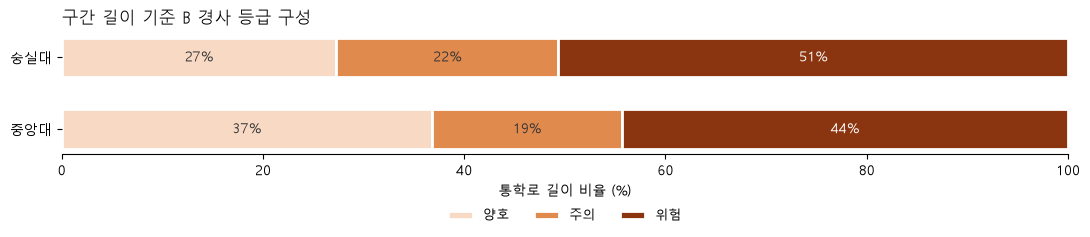

,종합 점수 (위험 길이 비율),확실한 위험 길이 비율 (13% 초과),길이 가중 평균 최대경사%,계단 구간
숭실대,51%,25%,9.8,3
중앙대,44%,25%,8.9,4


In [20]:
fig, ax = plt.subplots(figsize=(11, 2.8))
names = list(b_edges)
left = np.zeros(len(names))
for g in rb.GRADES:
    w = np.array([b_edges[s].loc[b_edges[s]['B등급'] == g, 'length_m'].sum() / b_edges[s]['length_m'].sum() * 100 for s in names])
    ax.barh(names, w, left=left, color=B_COLOR[g], edgecolor='white', linewidth=2, height=0.55, label=g)
    for yy, (l, v) in enumerate(zip(left, w)):
        if v >= 6:
            ax.text(l + v / 2, yy, f'{v:.0f}%', ha='center', va='center', fontsize=10,
                    color='white' if g == '위험' else '#333333')
    left += w
ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel('통학로 길이 비율 (%)')
for sp in ('top', 'right', 'left'):
    ax.spines[sp].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=3, fontsize=9, frameon=False)
ax.set_title('구간 길이 기준 B 경사 등급 구성', fontsize=12, loc='left')
plt.tight_layout()
plt.savefig('figures/risk_index/B_구간길이_구성.png', dpi=150, bbox_inches='tight')
plt.show()

rows = {}
for s, e in b_edges.items():
    L = e['length_m'].sum()
    sure = e[~e['기준선_근처']]
    rows[s] = {
        '종합 점수 (위험 길이 비율)': e.loc[e['B등급'] == '위험', 'length_m'].sum() / L,
        '확실한 위험 길이 비율 (13% 초과)': sure.loc[sure['B등급'] == '위험', 'length_m'].sum() / L,
        '길이 가중 평균 최대경사%': (e['최대경사_pct'] * e['length_m']).sum() / L,
        '계단 구간': int(e['계단'].sum()),
    }
b_summary = pd.DataFrame(rows).T
b_summary.style.format({'종합 점수 (위험 길이 비율)': '{:.0%}', '확실한 위험 길이 비율 (13% 초과)': '{:.0%}',
                        '길이 가중 평균 최대경사%': '{:.1f}', '계단 구간': '{:.0f}'})

### B-4. 민감도 — 기준 길이를 바꾸면

기준 길이를 50m·60m·80m로 바꿔 "위험" 길이 비율이 얼마나 달라지는지 본다.

In [21]:
rows = {}
for base in (50, 60, 80):
    for s, n in nets_b.items():
        e = rb.score_b(n, samples_b, base=base)
        L = e['length_m'].sum()
        rows[(s, f'{base}m')] = {g: e.loc[e['B등급'] == g, 'length_m'].sum() / L * 100 for g in rb.GRADES}
pd.DataFrame(rows).T.sort_index(level=0, sort_remaining=False).round(1).rename(columns=lambda c: f'{c} 길이%')

양호 길이%  주의 길이%  위험 길이%
숭실대 50m    25.1    21.6    53.3
    60m    27.3    22.1    50.6
    80m    33.3    17.0    49.7
중앙대 50m    36.2    14.3    49.4
    60m    36.8    18.9    44.3
    80m    42.5    16.2    41.3

### B-5. 저장

구간별 결과를 `data/risk_index/B_edges.csv`, `.geojson`으로 저장한다.

In [22]:
cols_b = ['u', 'v', 'key', 'highway', 'name', 'length_m', '기준길이_m', '조각수', '최대경사_pct', 'B등급', '기준선_근처', '계단']
allb = pd.concat([e.assign(학교=s) for s, e in b_edges.items()], ignore_index=True)
allb[['학교'] + cols_b].to_csv(out / 'B_edges.csv', index=False, encoding='utf-8-sig')
gpd.GeoDataFrame(allb[['학교'] + cols_b], geometry=allb.geometry, crs=rb.PROJ).to_crs(4326).to_file(
    out / 'B_edges.geojson', driver='GeoJSON')
print(len(allb), '개 구간 저장')

595 개 구간 저장


## C. 이동 인지 복잡성

걷는 동안 판단하거나 방향을 다시 잡아야 하는 순간(이벤트)이 많을수록 복잡하다. 계산 함수는 `risk_c_complexity.py`

| 이벤트 | 점수 | 찾는 방법 |
|---|---|---|
| 횡단 1회 | 일단 1 / 이단 2 | A에서 찾은 교차 지점 하나당. 횡단보도 없는 교차로는 1 |
| 급한 방향 전환 1회 | 1 | 구간 선을 2m 간격으로 나눈 뒤, 10m 안에서 방향이 45° 이상 바뀌는 곳 (이어서 꺾이는 곳은 1회) |

- **이단 횡단 = 2**: 횡단보도 - 중간 지점(교통섬·중앙 보행섬) - 횡단보도로 이어져 두 번에 나눠 건너는 형태. 중간에서 멈춰 방향을 다시 잡아야 해서 이벤트 2로 센다
  - 근거: 서울시 「교통안전시설물 테이블 정의서(횡단보도)」의 횡단보도종류 코드(001 일단(화살표있음), 002 이단(화살표있음), 003 일단(화살표없음), 004 이단(화살표없음), 005 삼단(화살표있음))에는 뜻 설명이 없음. 학술 정의는 "보행자가 도로를 두 번에 나누어 횡단하게 하는 횡단보도"(심관보 외, 2013, 한국ITS학회 논문지 12(6)). 팀원이 데이터에서 이런 형태를 확인함
  - 교차 지점에 횡단보도가 여러 개면 가장 큰 단수를 쓴다(A와 같은 규칙). C-3에서 모든 횡단을 1로 센 경우와 비교한다
- 교차로에서 다른 구간으로 꺾는 것은 어떤 경로로 가느냐에 따라 달라서 넣지 않는다. 구간 안에서 꺾이는 것만 센다
- **갈림길**(전체 보행망에서 세 갈래 이상 만나는 곳)은 점수에 넣지 않고 지도에 따로 표시한다
- **구간 C** = 구간 안 급한 전환 수 + 끝 교차 지점 이벤트를 그 지점에 붙은 통학로 구간 수로 나눈 몫. 교차 지점 하나를 여러 구간이 나눠 가지므로 구간 값을 모두 더하면 전체 이벤트 수와 같다

In [23]:
import risk_c_complexity as rc
importlib.reload(rc)
from shapely.geometry import LineString
print('확인용 — 직각:', rc.sharp_turns(LineString([(0, 0), (50, 0), (50, 50)])),
      '/ 직선:', rc.sharp_turns(LineString([(0, 0), (100, 0)])),
      '/ 반지름 50m 완만한 90° 곡선:', rc.sharp_turns(LineString([(50 * np.sin(t), 50 - 50 * np.cos(t)) for t in np.linspace(0, np.pi / 2, 60)])),
      '/ 두 번 꺾임:', rc.sharp_turns(LineString([(0, 0), (40, 0), (40, 40), (80, 40)])))

c_res = {s: rc.score_c(s, pts) for s in ra.SCHOOLS}
c_summary = pd.DataFrame({s: rc.summarize(*r) for s, r in c_res.items()}).T
c_summary.round(2)

확인용 — 직각: 1 / 직선: 0 / 반지름 50m 완만한 90° 곡선: 0 / 두 번 꺾임: 2


,통학로 길이 (km),교차 지점,이단 이상 지점,횡단 이벤트,급한 전환,C 이벤트 합,1km당 C 이벤트,1km당 횡단,1km당 급한 전환,1km당 갈림길
숭실대,22.89,44.0,22.0,66.0,83.0,149.0,6.51,2.88,3.63,11.58
중앙대,23.39,65.0,34.0,99.0,69.0,168.0,7.18,4.23,2.95,10.22


### C-1. 지도

구간 색이 진할수록 이벤트가 많다. 검은 점 = 교차 지점(횡단 이벤트), 회색 작은 원 = 갈림길(점수 제외, 참고용).

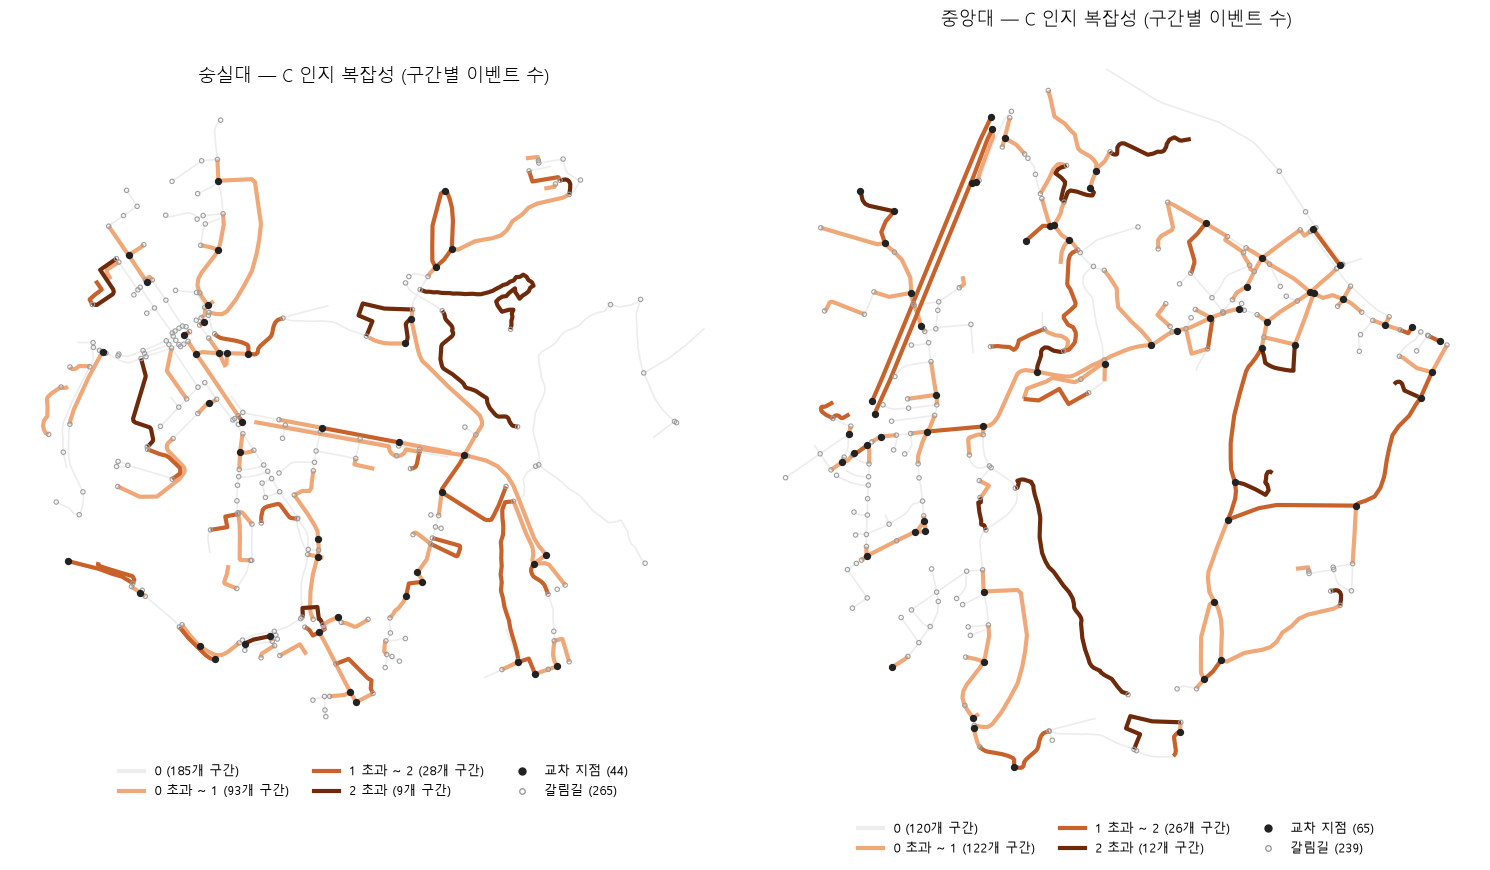

In [24]:
C_BINS = [(0, 0, '0'), (0, 1, '0 초과 ~ 1'), (1, 2, '1 초과 ~ 2'), (2, 99, '2 초과')]
C_COLOR = {'0': '#EDEDED', '0 초과 ~ 1': '#F0A878', '1 초과 ~ 2': '#C8612A', '2 초과': '#6E2A0A'}
def c_bin(v):
    if v == 0:
        return '0'
    for lo, hi, lab in C_BINS[1:]:
        if lo < v <= hi:
            return lab
fig, axes = plt.subplots(1, 2, figsize=(15, 8.5))
for ax, s in zip(axes, ra.SCHOOLS):
    an, jn, cn = c_res[s]
    an['C구간'] = an['C이벤트'].map(c_bin)
    for z, (_, _, lab) in enumerate(C_BINS):
        g = an[an['C구간'] == lab]
        if len(g):
            g.plot(ax=ax, color=C_COLOR[lab], linewidth=1.2 if lab == '0' else 3.0, zorder=z + 1)
    ax.scatter(jn.x, jn.y, s=10, facecolors='none', edgecolors='#9E9E9E', linewidths=0.8, zorder=6)
    ax.scatter(cn.x, cn.y, s=18, color='#222222', zorder=7)
    cnt = an['C구간'].value_counts()
    handles = [Line2D([], [], color=C_COLOR[lab], lw=3, label=f'{lab} ({cnt.get(lab, 0)}개 구간)') for _, _, lab in C_BINS]
    handles += [Line2D([], [], marker='o', ls='', ms=5, color='#222222', label=f'교차 지점 ({len(cn)})'),
                Line2D([], [], marker='o', ls='', ms=4, mfc='none', mec='#9E9E9E', label=f'갈림길 ({len(jn)})')]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=3, fontsize=9, frameon=False)
    ax.set_title(f'{s} — C 인지 복잡성 (구간별 이벤트 수)', fontsize=13)
    ax.set_axis_off(); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('figures/risk_index/C_인지복잡성_지도.png', dpi=150, bbox_inches='tight')
plt.show()

### C-2. 학교 비교

**학교 종합 점수** = 1km당 C 이벤트 수(횡단 + 급한 전환). 갈림길은 참고로만 본다.

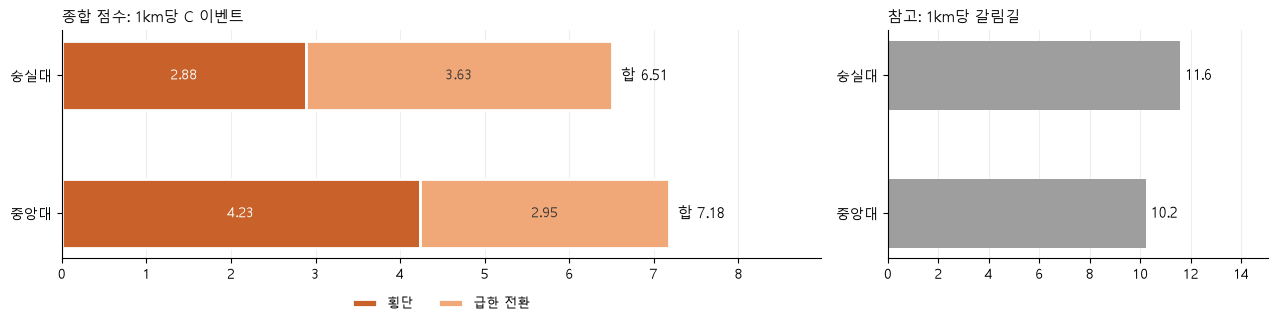

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), gridspec_kw={'width_ratios': [2, 1]})
names = list(c_summary.index)
y = np.arange(len(names))
ax = axes[0]
a = c_summary['1km당 횡단'].to_numpy(dtype=float)
b = c_summary['1km당 급한 전환'].to_numpy(dtype=float)
ax.barh(y, a, color='#C8612A', height=0.5, label='횡단', edgecolor='white', linewidth=2)
ax.barh(y, b, left=a, color='#F0A878', height=0.5, label='급한 전환', edgecolor='white', linewidth=2)
for i in range(len(names)):
    ax.text(a[i] / 2, i, f'{a[i]:.2f}', ha='center', va='center', color='white', fontsize=10)
    ax.text(a[i] + b[i] / 2, i, f'{b[i]:.2f}', ha='center', va='center', color='#333333', fontsize=10)
    ax.text(a[i] + b[i] + 0.1, i, f'합 {a[i] + b[i]:.2f}', va='center', fontsize=11)
ax.set_xlim(0, (a + b).max() * 1.25)
ax.set_title('종합 점수: 1km당 C 이벤트', fontsize=11, loc='left')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False, fontsize=9)
ax = axes[1]
v = c_summary['1km당 갈림길'].to_numpy(dtype=float)
ax.barh(y, v, color='#9E9E9E', height=0.5)
for i, t in enumerate(v):
    ax.text(t + 0.2, i, f'{t:.1f}', va='center', fontsize=11)
ax.set_xlim(0, v.max() * 1.3)
ax.set_title('참고: 1km당 갈림길', fontsize=11, loc='left')
for ax in axes:
    ax.set_yticks(y, names); ax.invert_yaxis()
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.grid(axis='x', color='#EEEEEE'); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('figures/risk_index/C_학교_종합비교.png', dpi=150, bbox_inches='tight')
plt.show()

### C-3. 민감도 — 45°·10m 기준을 바꾸면

각도 30°·45°·60°, 거리 5m·10m·20m로 바꿔 급한 전환 수와, 기본 기준(45°·10m)과의 구간 순위 상관(스피어만)을 본다. 마지막 표는 이단을 2가 아니라 1로 센 경우다.

In [26]:
from scipy.stats import spearmanr
rows = {}
for s, (an, jn, cn) in c_res.items():
    base = an['급한전환'].to_numpy()
    km = an['length_m'].sum() / 1000
    for ang in (30, 45, 60):
        for w in (5, 10, 20):
            t = np.array([rc.sharp_turns(g, ang, w) for g in an.geometry])
            rows[(s, f'{ang}° / {w}m')] = {'급한 전환 수': int(t.sum()), '1km당': t.sum() / km,
                                          '기본 기준과 순위 상관': spearmanr(base, t)[0]}
c_sens = pd.DataFrame(rows).T
c_sens.round(2)

stage = pd.DataFrame({s: {'이단=2 (기본)': rc.summarize(*c_res[s])['1km당 C 이벤트'],
                          '모든 횡단=1': rc.summarize(*rc.score_c(s, pts, stage_weight=False))['1km당 C 이벤트']}
                      for s in ra.SCHOOLS}).T
print()
print('1km당 C 이벤트 — 이단 가중 여부'); print(stage.round(2))


1km당 C 이벤트 — 이단 가중 여부
     이단=2 (기본)  모든 횡단=1
숭실대       6.51     5.55
중앙대       7.18     5.73


### C-4. 저장

구간별 결과를 `data/risk_index/C_edges.csv`, `.geojson`으로 저장한다.

In [27]:
cols_c = ['u', 'v', 'key', 'highway', 'name', 'length_m', '급한전환', '횡단_배분', 'C이벤트']
allc = pd.concat([r[0].assign(학교=s) for s, r in c_res.items()], ignore_index=True)
allc[['학교'] + cols_c].to_csv(out / 'C_edges.csv', index=False, encoding='utf-8-sig')
gpd.GeoDataFrame(allc[['학교'] + cols_c], geometry=allc.geometry, crs=rb.PROJ).to_crs(4326).to_file(
    out / 'C_edges.geojson', driver='GeoJSON')
print(len(allc), '개 구간 저장')

595 개 구간 저장
